# 🏠 House Price Prediction using Scikit-learn

## Project Overview

This project aims to predict house prices using machine learning.

In this project, I will build a complete machine learning workflow using
Scikit-learn, including data understanding, exploratory data analysis,
data preprocessing, feature engineering, model training, cross-validation,
and model evaluation.

### Objective

To predict house prices based on various property features and evaluate
the performance of a Linear Regression model.

### Machine Learning Algorithm

- Linear Regression

### Libraries

- Python
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn

## 1. Import Libraries

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. Load Dataset

In [59]:
df = pd.read_csv("../data/Housing.csv")

In [60]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420.0,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960.0,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960.0,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500.0,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420.0,4,1,2,yes,yes,NaN,no,yes,2,no,unfurnished


In [61]:
df.shape

(545, 13)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             545 non-null    int64  
 1   area              544 non-null    float64
 2   bedrooms          545 non-null    int64  
 3   bathrooms         545 non-null    int64  
 4   stories           545 non-null    int64  
 5   mainroad          545 non-null    object 
 6   guestroom         545 non-null    object 
 7   basement          544 non-null    object 
 8   hotwaterheating   545 non-null    object 
 9   airconditioning   545 non-null    object 
 10  parking           545 non-null    int64  
 11  prefarea          545 non-null    object 
 12  furnishingstatus  545 non-null    object 
dtypes: float64(1), int64(5), object(7)
memory usage: 55.5+ KB


In [63]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,544.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5143.832721,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2166.474646,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3596.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4580.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [64]:
df.isnull().sum()

price               0
area                1
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            1
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [65]:
df.duplicated().sum()

np.int64(0)

# 3. Data Understanding

### Dataset Overview

- The dataset contains 545 rows and 13 columns.
- `price` is the target variable.
- The dataset contains both numerical and categorical features.
- There are 6 numerical columns including the target variable.
- There are 7 categorical feature columns.
- Missing values are present in `area` and `basement`.
- No duplicate rows are present.

In [66]:
target = "price"
X = df.drop(target, axis=1)
y = df[target]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

Categorical Features:
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


# 4. EDA

## 4.1 Target Distribution

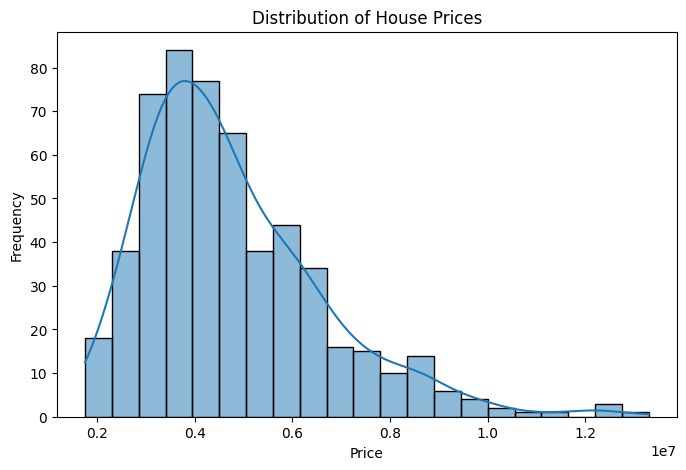

In [67]:
plt.figure(figsize=(8, 5))

sns.histplot(df["price"], kde=True)  #type:ignore

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.savefig('../images/Distribution-of-House-Prices', dpi=300, bbox_inches='tight')

plt.show()

## 4.2 Numerical Feature Analysis

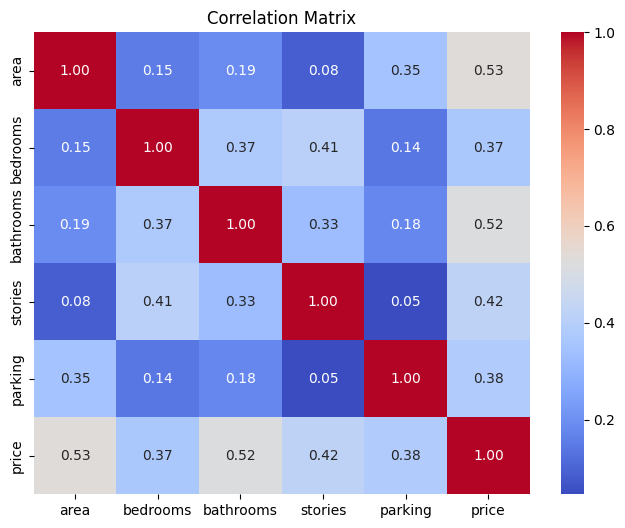

In [68]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[numeric_features + ["price"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.savefig('../images/Correlation-Matrix', dpi=300, bbox_inches='tight')
plt.show()

## 4.3 Categorical Feature

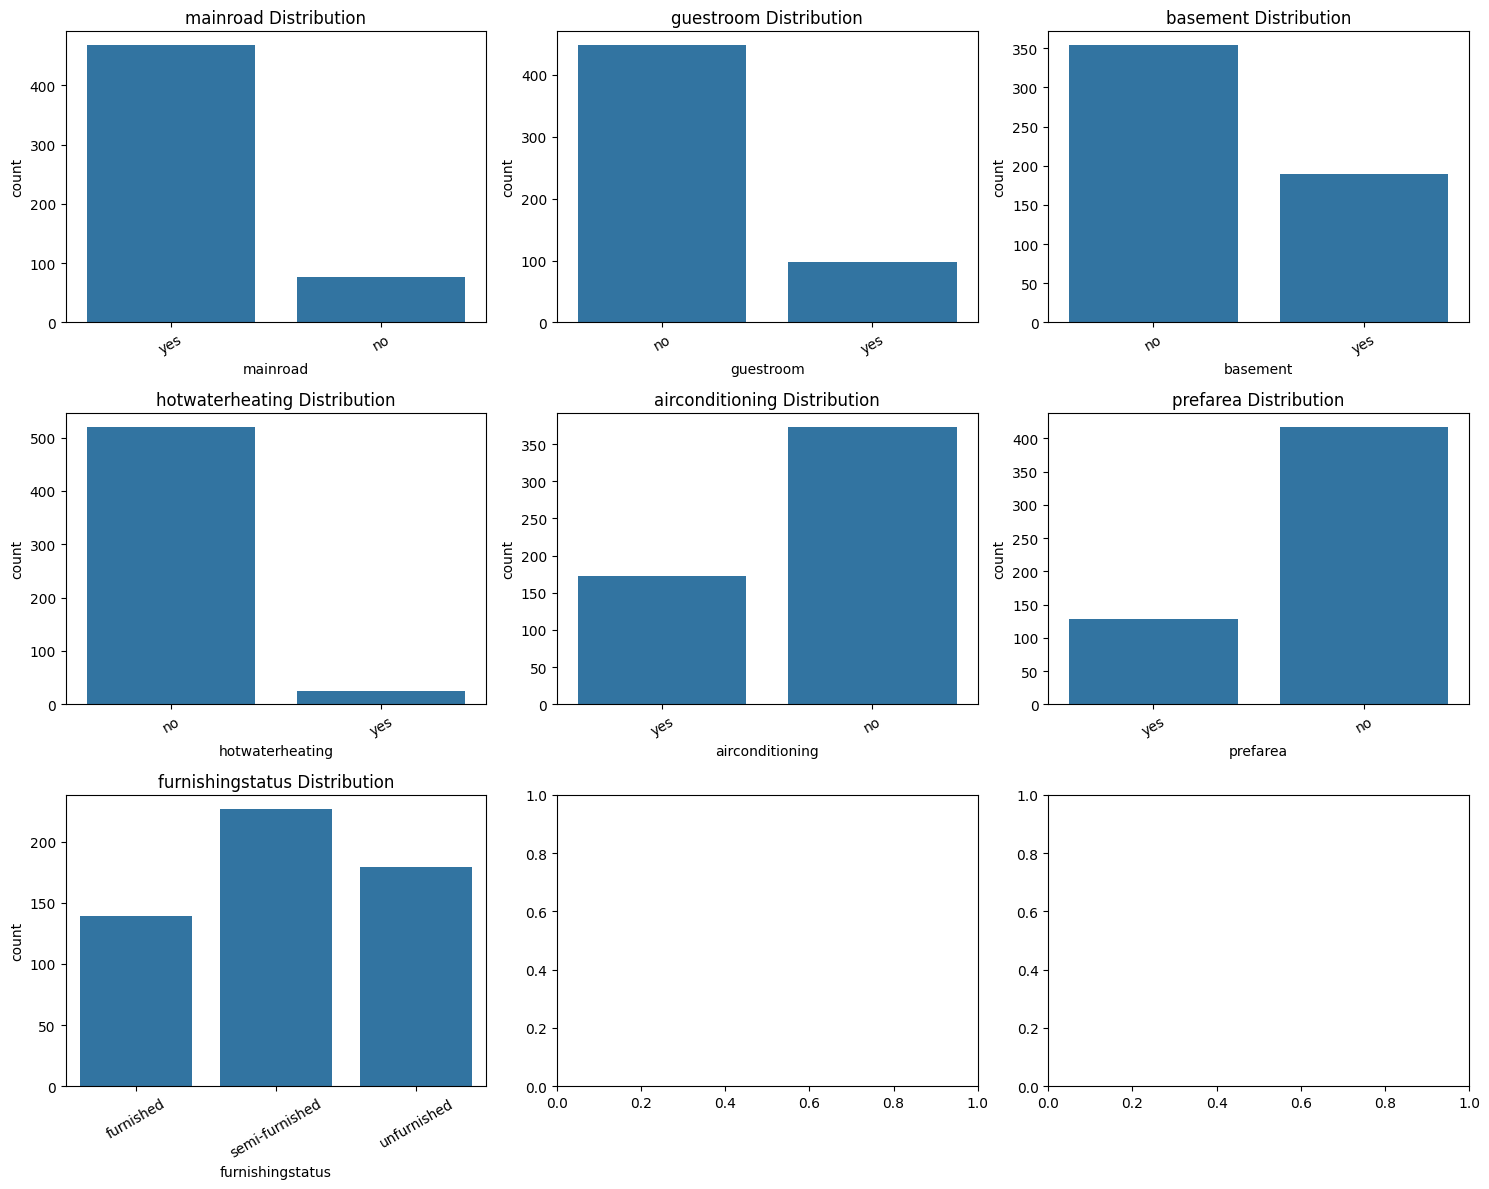

In [69]:
fig, axes = plt.subplots(
    3, 3,
    figsize=(15, 12)
)

for ax, column in zip(
    axes.flatten(),
    categorical_features
):
    sns.countplot(
        data=df,
        x=column,
        ax=ax
    )
    ax.set_title(f"{column} Distribution")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig('../images/Distribution', dpi=300, bbox_inches='tight')
plt.show()

# 5. Train/Test Split + Missing Value Handling

## 5.1 Separate Feature and Target

In [70]:
X = df.drop("price", axis=1)
y = df["price"]

## 5.2 Train/Test Split

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [72]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (436, 12)
X_test: (109, 12)
y_train: (436,)
y_test: (109,)


## 5.3 Numerical and Categorical Columns

In [73]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categoric_feature = X.select_dtypes(include="object").columns.tolist()

## 5.4 Handle missing values with SimpleImputer

In [74]:
from sklearn.impute import SimpleImputer
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

## 5.5 Combine them with ColumnTransformer

In [75]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## 5.6 Quick Check

In [76]:
print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Numerical features: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical features: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
Training shape: (436, 12)
Testing shape: (109, 12)


# 6. Build the ML Pipeline

In [77]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# 7. Train the Model

In [78]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

# 8. Make Prediction

In [79]:
y_pred = model.predict(X_test)

In [80]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,4060000,5.138943e+06
1,6650000,7.208547e+06
2,3710000,3.117107e+06
3,6440000,4.635073e+06
4,2800000,3.272911e+06
5,4900000,3.572614e+06
6,5250000,5.612789e+06
7,4543000,6.332344e+06
8,2450000,2.814300e+06
9,3353000,2.594871e+06


# 9. Evaluation

In [81]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:,.2f}")
print(f"MSE : {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²  : {r2:.4f}")

MAE : 962,528.89
MSE : 1,747,306,340,574.99
RMSE: 1,321,857.16
R²  : 0.6543


# 10. Cross Validation

In [82]:
cv = cross_val_score(
    model,
    X_train, 
    y_train,
    cv = 5,
    scoring="r2"
)

In [83]:
print("CV Scores:", cv)
print("Mean CV R²:", cv.mean())
print("Std CV R²:", cv.std())

CV Scores: [0.68755012 0.68028576 0.61150748 0.59150207 0.62049798]
Mean CV R²: 0.6382686815679557
Std CV R²: 0.03850498937984952


# 11. Error Analysis

## 11.1 Residuals

In [84]:
residuals = y_test - y_pred
print("Mean Residuals:", residuals.mean())
print("Minimum Residual:", residuals.min())
print("Maximum Residual:", residuals.max())

Mean Residuals: 136026.14288155086
Minimum Residual: -2702684.9150577793
Maximum Residual: 5318192.665938472


## 11.2 Residuasls vs Predicted Price

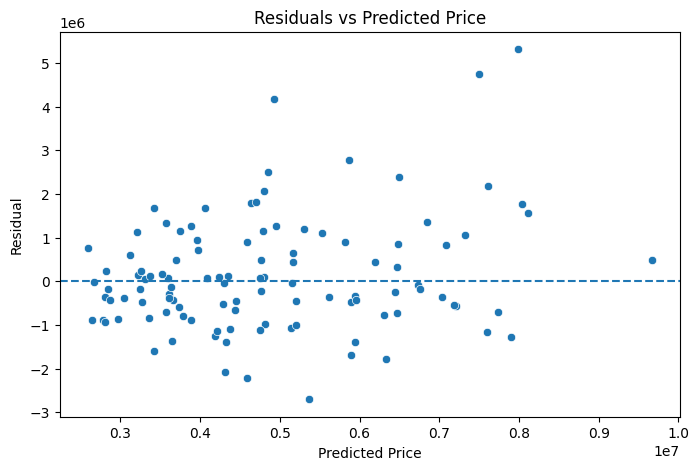

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x=y_pred, y=residuals) #type:ignore

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Price")
plt.savefig('../images/Residuals-Predicted Price', dpi=300, bbox_inches='tight')
plt.show()

## 11.3 Actual vs Predicted Price

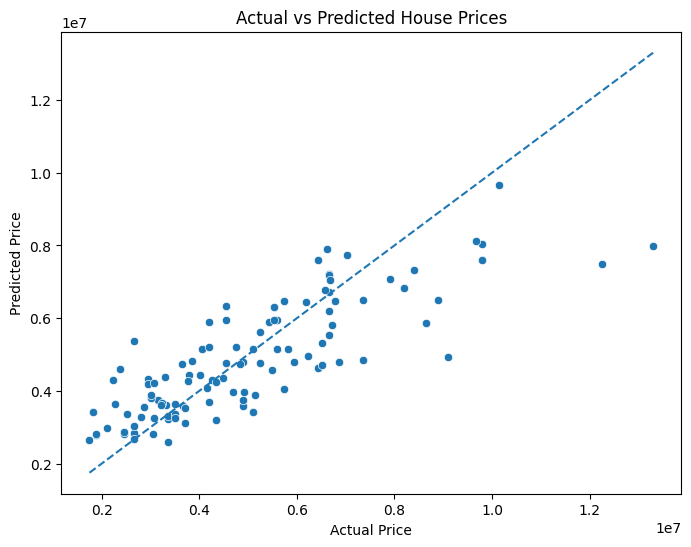

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=y_pred) #type:ignore

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.savefig('../images/Actual-Predicted Price', dpi=300, bbox_inches='tight')
plt.show()

# 12. 📊 Model Performance Comparison

### 🔹 Linear Regression — From Scratch

| **Metric** | **Value** |
|---|---:|
| **MAE** | ₹779,710.27 |
| **MSE** | 1.146 × 10¹² |
| **RMSE** | ₹1,070,742.18 |
| **R² Score** | **0.6609** |

The model explains approximately **66.09% of the variance in house prices**.

---

### 🔹 Linear Regression — Scikit-learn

| **Metric** | **Value** |
|---|---:|
| **MAE** | ₹962,528.89 |
| **MSE** | 1.747 × 10¹² |
| **RMSE** | ₹1,321,857.16 |
| **R² Score** | **0.6543** |
| **Mean CV R²** | **0.6383** |

The model explains approximately **65.43% of the variance in house prices** on the test set.

---

### 📈 Overall Comparison

| **Metric** | **From Scratch** | **Scikit-learn** |
|---|---:|---:|
| **MAE** | ₹779,710.27 | ₹962,528.89 |
| **MSE** | 1.146 × 10¹² | 1.747 × 10¹² |
| **RMSE** | ₹1,070,742.18 | ₹1,321,857.16 |
| **R² Score** | **0.6609** | **0.6543** |
| **Mean CV R²** | — | **0.6383** |

### 📝 Observation

The **From-Scratch Linear Regression** achieved slightly better performance on the test set, with lower MAE, MSE, and RMSE and a slightly higher R² score.

The **Scikit-learn implementation** provides a more structured and reusable machine learning workflow using missing-value handling, categorical encoding, feature preprocessing, pipelines, and cross-validation.

This project demonstrates both the **implementation of Linear Regression from scratch** and its **practical implementation using Scikit-learn**.

# 13. Final Model

In [87]:
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

final_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

# 14. User Input Prediction

In [88]:
def predict_house_price(
    area,
    bedrooms,
    bathrooms,
    stories,
    mainroad,
    guestroom,
    basement,
    hotwaterheating,
    airconditioning,
    parking,
    prefarea,
    furnishingstatus
):
    
    user_data = pd.DataFrame({
        "area": [area],
        "bedrooms": [bedrooms],
        "bathrooms": [bathrooms],
        "stories": [stories],
        "mainroad": [mainroad],
        "guestroom": [guestroom],
        "basement": [basement],
        "hotwaterheating": [hotwaterheating],
        "airconditioning": [airconditioning],
        "parking": [parking],
        "prefarea": [prefarea],
        "furnishingstatus": [furnishingstatus]
    })

    prediction = final_model.predict(user_data)

    return prediction[0]

In [96]:
user_data = pd.DataFrame({
    "area": [7500],
    "bedrooms": [4],
    "bathrooms": [2],
    "stories": [3],
    "mainroad": ["yes"],
    "guestroom": ["no"],
    "basement": ["yes"],
    "hotwaterheating": ["no"],
    "airconditioning": ["yes"],
    "parking": [2],
    "prefarea": ["yes"],
    "furnishingstatus": ["furnished"]
})
print(user_data)
print(type(user_data))

   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  7500         4          2        3      yes        no      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
<class 'pandas.core.frame.DataFrame'>


In [ ]:
prediction = loaded_model.predict(user_data) #type:ignore

print(f"Predicted House Price: ₹{prediction[0]:,.2f}")

Predicted House Price: ₹8,459,393.44


# 15. Save the Final Model

## 15.1 Install/use joblib

In [90]:
import joblib

In [101]:
import joblib

model_path = "../models/house_price_model.pkl"

loaded_model = joblib.load(model_path)

# 16. Test the Save Model

In [102]:
price = loaded_model.predict(user_data)

print(f"Predicted House Price: ₹{price[0]:,.2f}")

Predicted House Price: ₹8,459,393.44
